In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns



## Load the dataset

In [3]:
# Load the preprocessed DataFrame
df = pd.read_pickle("../data/interim/df_dtypes_fixed.pkl")

## Define variables

In [81]:
X = df.drop(columns = ['is_fraud', 'fraud_type'])

We drop the **`fraud_type`** column, as it is not suitable for predicting fraudulent transactions and may introduce unnecessary complexity.
We also drop the **`transaction_id`** column, as it serves only as an identifier and does not provide predictive value.

In [5]:
y = df['is_fraud']

## Train/Test Split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

We use **stratification** because the target class is heavily imbalanced, and we want to preserve the distribution of the fraud class.

## Handling missing values

In [83]:
X_train.isna().sum()

transaction_id                              0
timestamp                                   2
sender_account                              0
receiver_account                            0
amount                                      0
transaction_type                            0
merchant_category                           0
location                                    0
device_used                                 0
time_since_last_transaction            717703
spending_deviation_score                    0
velocity_score                              0
geo_anomaly_score                           0
payment_channel                             0
ip_address                                  0
device_hash                                 0
time_since_last_transaction_missing         0
dtype: int64

We drop the two rows with missing **`timestamp`** values, as they represent a negligible portion of the dataset.

We will use **User-Level Median Imputation** to handle missing values in the **`time_since_last_transaction`** column. This strategy preserves each user's typical behavior and minimizes the impact on fraud detection signals.  

The median will be computed **only on the training dataset**, and the same transformation will be applied to the test dataset.

In [84]:
X_train = X_train.dropna(subset=['timestamp'])

In [85]:
X_test["timestamp"].isna().sum()

np.int64(1)

We apply the same step to the test dataset as well.

In [86]:
X_test = X_test.dropna(subset=['timestamp'])

In [87]:
# Compute per-sender median on training data
user_medians = X_train.groupby('sender_account')['time_since_last_transaction'].median()

# Map medians to the training data
X_train['time_since_last_transaction'] = X_train['time_since_last_transaction'].fillna(
    X_train['sender_account'].map(user_medians)
)


In [88]:
# Count remaining missing values
remaining_missing = X_train['time_since_last_transaction'].isna().sum()

# Calculate percentage
total_rows = len(X_train)
missing_percent = (remaining_missing / total_rows) * 100

print(f"Remaining missing values: {remaining_missing}")
print(f"Percentage of missing values: {missing_percent:.2f}%")

Remaining missing values: 28432
Percentage of missing values: 0.71%


Approximately **0.71% of the rows** belong to users for whom all values in the **`time_since_last_transaction`** column are missing. These missing values are likely **not due to data errors**; instead, they correspond to new users who appear only once in the dataset. In this case, leaving the values as NaN is appropriate.  

We will also adjust the missing-value flag to capture only users with entirely missing values in this column.  

For such users, leaving **`time_since_last_transaction`** as NaN preserves behavioral information instead of averaging it away. This missingness is **informative for fraud detection**, signaling to the model that the account is new or low-activity, which may correlate with certain types of fraud.

In [89]:
# adjust the missing-value flag to capture only users with entirely missing history, not just individual transactions
X_train['time_since_last_transaction_missing'] = X_train['time_since_last_transaction'].isnull().astype(int)

Next, we apply the same logic to the test dataset, completing the missing-value imputation process.

In [90]:
# Map training medians to test data
X_test['time_since_last_transaction'] = X_test['time_since_last_transaction'].fillna(
    X_test['sender_account'].map(user_medians)
)

# Add missingness flag for test data
X_test['time_since_last_transaction_missing'] = X_test['time_since_last_transaction'].isna().astype(int)

## Fixing problemetic values

Next, we examine the features **`amount`** and **`time_since_last_transaction`** for invalid negative values, out-of-range values, extreme outliers, and unusual distributions, while excluding other numeric features as they were previously identified as well-engineered in the initial notebook.
In addition, we examine the **`timestamp`** column to determine the time range covered by the observations.

In [91]:
stats_table = X_train[['amount', 'time_since_last_transaction', 'timestamp']].describe(percentiles=[.01, .25, .5, .75, .9, .99])
stats_table

,amount,time_since_last_transaction,timestamp
count,3.999998e+06,3.971566e+06,3999998
mean,3.586044e+02,1.185023e+00,2023-07-02 23:30:32.073422
min,1.000000e-02,-8.777814e+03,2023-01-01 00:09:26.241974
1%,1.000000e-02,-7.415783e+03,2023-01-05 03:05:17.076935
25%,2.654000e+01,-2.207120e+03,2023-04-02 17:57:40.075809
50%,1.383300e+02,1.814732e+00,2023-07-03 00:24:31.386949
75%,5.032500e+02,2.210682e+03,2023-10-02 03:57:41.445373
90%,1.125950e+03,4.523218e+03,2023-11-25 22:07:35.249739
99%,1.874110e+03,7.414888e+03,2023-12-28 18:58:27.601108
max,3.520570e+03,8.757758e+03,2024-01-01 22:58:30.131850


In [12]:
X_train["spending_deviation_score"].describe()


count    4.000000e+06
mean    -3.683350e-04
std      1.000915e+00
min     -5.260000e+00
25%     -6.800000e-01
50%      0.000000e+00
75%      6.700000e-01
max      5.020000e+00
Name: spending_deviation_score, dtype: float64

### amount
- Strong right skew (median ≈ 138 vs mean ≈ 359)
- Large but realistic outliers (max ≈ 3520)
- No obvious errors such as negative values → we keep it, but are going to transform it later (log)

### timestamp
- Covers full year (Jan 2023 → Jan 2024)
- Even distribution → suitable for time-based feature extraction







### time_since_last_transaction

An analysis of the descriptive statistics for **`time_since_last_transaction`** indicates that this feature is **standardized (scaled and centered)** rather than representing a raw temporal measurement or resulting from a sorting error.  

**Key evidence for standardization:**
- **Near-zero central tendency:** The mean (≈ 1.18) and median (≈ 1.81) are negligible compared to the standard deviation (≈ 3,353), indicating mean-centering.  
- **Symmetry:** The percentiles are nearly mirrored around zero (e.g., 25th percentile ≈ -2,207 vs. 75th percentile ≈ 2,210), a typical characteristic of standardized features.  
- **Exclusion of sorting errors:** While unsorted data can produce negative values, the consistent and balanced distribution strongly suggests a deliberate transformation (e.g., standard scaling).  

**Interpretation of values:**
- Negative values indicate transaction intervals shorter than the average.  
- Positive values indicate intervals longer than the average.  

Thus, negative values do not represent invalid or corrupted data, but rather reflect relative deviations from the mean.

## Feature Construction
### Time-Based Features

We apply each feature creation to the test dataset in the same manner, since no parameters need to be learned from it.

In [92]:
X_train['hour_of_day'] = X_train['timestamp'].dt.hour
X_test['hour_of_day'] = X_test['timestamp'].dt.hour

In [93]:
X_train["at_night"] = X_train['hour_of_day'].isin([21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
X_test["at_night"] = X_test['hour_of_day'].isin([21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)

In [94]:
X_train['weekday'] = X_train['timestamp'].dt.weekday # Monday=0, Sunday=6
X_test['weekday'] = X_test['timestamp'].dt.weekday

In [95]:
X_train["on_weekend"] = X_train['weekday'].isin([5, 6]).astype(int)
X_test["on_weekend"] = X_test['weekday'].isin([5, 6]).astype(int)

### Transforming the Skewed Feature **`amount`**

In [96]:
X_train["log_amount"] = np.log(X_train["amount"])

Since transforming the **`amount`** feature using a log transformation does not require learning any parameters, we can apply the same transformation directly to the test dataset.

In [97]:
X_test["log_amount"] = np.log(X_test["amount"])

In [98]:
X_train["velocity_score"].describe()

count    3.999998e+06
mean     1.050116e+01
std      5.766916e+00
min      1.000000e+00
25%      5.000000e+00
50%      1.100000e+01
75%      1.600000e+01
max      2.000000e+01
Name: velocity_score, dtype: float64

### Interaction Features

The main idea behind creating interaction features is that fraud is rarely driven by a single variable; rather, it emerges from combinations of multiple signals.  

 The threshold defining "high" is learned from the training set only, so we simply adopt the same logic for the test set without recalculating it.

<Axes: >

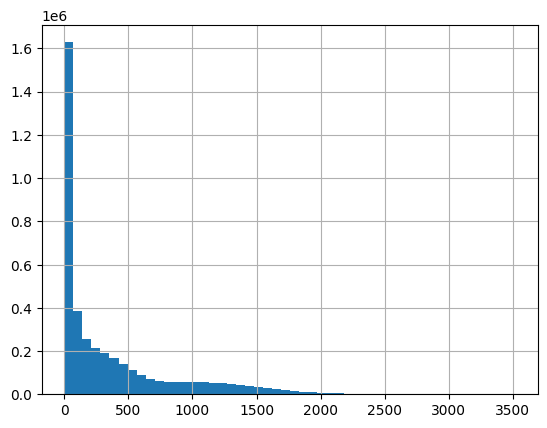

In [59]:
X_train["amount"].hist(bins=50)

In [62]:
X_train["amount"].describe()

count    3.999998e+06
mean     3.586044e+02
std      4.696906e+02
min      1.000000e-02
25%      2.654000e+01
50%      1.383300e+02
75%      5.032500e+02
max      3.520570e+03
Name: amount, dtype: float64

In [63]:
X_train["velocity_score"].describe()

count    3.999998e+06
mean     1.050116e+01
std      5.766916e+00
min      1.000000e+00
25%      5.000000e+00
50%      1.100000e+01
75%      1.600000e+01
max      2.000000e+01
Name: velocity_score, dtype: float64

In [100]:
# High amount + high velocity 
# We define "high" as above the , which corresponds to an amount greater than 503 and a velocity score greater than 1.6 in our training data.
X_train["high_amount_and_velocity"] = ((X_train["amount"] > 503) & (X_train["velocity_score"] > 1.6)).astype(int)
X_test["high_amount_and_velocity"] = ((X_test["amount"] > 503) & (X_test["velocity_score"] > 1.6)).astype(int)


In [55]:
X_train["geo_anomaly_score"].describe()

count    3.999998e+06
mean     5.000099e-01
std      2.886466e-01
min      0.000000e+00
25%      2.500000e-01
50%      5.000000e-01
75%      7.500000e-01
max      1.000000e+00
Name: geo_anomaly_score, dtype: float64

In [101]:
# High geo anomyly + high velocity
# We define "high" as above the 75th percentile for both features, which corresponds to a geo anomaly score greater than 0.75 and a velocity score greater than 1.6 in our training data.   

X_train["high_geo_anomaly_and_velocity"] = ((X_train["geo_anomaly_score"] > 0.75) & (X_train["velocity_score"] > 1.6)).astype(int)
X_test["high_geo_anomaly_and_velocity"] = ((X_test["geo_anomaly_score"] > 0.75) & (X_test["velocity_score"] > 1.6)).astype(int)

In [102]:
X_train["spending_deviation_score"].describe()

count    3.999998e+06
mean    -3.683052e-04
std      1.000914e+00
min     -5.260000e+00
25%     -6.800000e-01
50%     -0.000000e+00
75%      6.700000e-01
max      5.020000e+00
Name: spending_deviation_score, dtype: float64

In [103]:
# High deviation + high amount
# We define "high" as above the 75th percentile for both features, which corresponds to a spending deviation score greater than 0.67 and an amount greater than 503 in our training data.   

X_train["high_deviation_and_amount"] = ((X_train["spending_deviation_score"] > 0.67) & (X_train["amount"] > 503)).astype(int)
X_test["high_deviation_and_amount"] = ((X_test["spending_deviation_score"] > 0.67) & (X_test["amount"] > 503)).astype(int)

In [104]:
X_train.columns

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash',
       'time_since_last_transaction_missing', 'hour_of_day', 'at_night',
       'weekday', 'on_weekend', 'log_amount', 'high_amount_and_velocity',
       'high_geo_anomaly_and_velocity', 'high_deviation_and_amount'],
      dtype='str')

In [105]:
X_train["time_since_last_transaction"].quantile(0.25)

np.float64(-2207.120023728403)

In [106]:
# low time since last transaction + high geo anomaly
# We define "low" as below the 25th percentile for time since last transaction (<-2207) and "high" as above the 75th percentile for geo anomaly score (>0.75) in our training data.

X_train["low_time_and_high_geo_anomaly"] = ((X_train["time_since_last_transaction"] < -2207) & (X_train["geo_anomaly_score"] > 0.75)).astype(int)
X_test["low_time_and_high_geo_anomaly"] = ((X_test["time_since_last_transaction"] < -2207) & (X_test["geo_anomaly_score"] > 0.75)).astype(int)

In [107]:
# low time + high spending deviation
# We define "low" as below the 25th percentile for time since last transaction (<-2207) and "high" as above the 75th percentile for spending deviation score (>0.67) in our training data.  

X_train["low_time_and_high_deviation"] = ((X_train["time_since_last_transaction"] < -2207) & (X_train["spending_deviation_score"] > 0.67)).astype(int)
X_test["low_time_and_high_deviation"] = ((X_test["time_since_last_transaction"] < -2207) & (X_test["spending_deviation_score"] > 0.67)).astype(int)

### Binary/ flag Features

The idea here is to convert complex values into simple yes/no signals; for example, determining whether **`amount`** is extremely high.

We only consider values classified as "very high," defined as those above the 95th percentile.

In [108]:
X_train["amount"].quantile(0.95)

np.float64(1419.79)

In [109]:
X_train["very_high_amount"] = (X_train["amount"] > 1420).astype(int)
X_test["very_high_amount"] = (X_test["amount"] > 1420).astype(int)

In [110]:
X_train["geo_anomaly_score"].quantile(0.95)

np.float64(0.95)

In [111]:
X_train["very_high_geo_anomaly"] = (X_train["geo_anomaly_score"] > 0.95).astype(int)
X_test["very_high_geo_anomaly"] = (X_test["geo_anomaly_score"] > 0.95).astype(int)

In [112]:
X_train["velocity_score"].quantile(0.95)

np.float64(19.0)

In [113]:
X_train["very_high_velocity"] = (X_train["velocity_score"] > 19).astype(int)
X_test["very_high_velocity"] = (X_test["velocity_score"] > 19).astype(int)

In [114]:
X_train["time_since_last_transaction"].quantile(0.95) 


np.float64(5754.960328735902)

In [115]:
# We will create a column long_inactivity which flags transactions from users who have been inactive for a long time, defined as having a time since last transaction greater than the 95th percentile  in our training data, which corresponds to a value greater than 5755.

X_train["long_inactivity"] = (X_train["time_since_last_transaction"] > 5755).astype(int)
X_test["long_inactivity"] = (X_test["time_since_last_transaction"] > 5755).astype(int)    

### Aggregation Features

The main idea is to leverage behavior across multiple transactions to create user-specific aggregated features that are not directly available in the raw data.

In [121]:
# 1. Compute transaction count per sender on training data
transaction_counts = X_train.groupby("sender_account").size()

# 2. Map to training data
X_train["transactions_per_sender"] = X_train["sender_account"].map(transaction_counts)

# 3. Map to test data (IMPORTANT: use train stats!)
X_test["transactions_per_sender"] = X_test["sender_account"].map(transaction_counts)

In [120]:
# 1. Compute averages ONLY on training data
sender_avg = X_train.groupby("sender_account")["amount"].mean()

# 2. Map to training data
X_train["avg_transaction_amount_per_sender"] = X_train["sender_account"].map(sender_avg)

# 3. Map to test data (IMPORTANT: use train stats!)
X_test["avg_transaction_amount_per_sender"] = X_test["sender_account"].map(sender_avg)

In [122]:
unique_receivers_per_sender = X_train.groupby("sender_account")["receiver_account"].nunique()

# Map to training data
X_train["unique_receivers_per_sender"] = X_train["sender_account"].map(unique_receivers_per_sender)

# Map to test data (IMPORTANT: use train stats!)
X_test["unique_receivers_per_sender"] = X_test["sender_account"].map(unique_receivers_per_sender)